In [1]:
import torch.nn as nn
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor

import math



import torch

mnist_model_path = r'C:\Users\Articuno\Desktop\TFG-info\data\models\dif_mnist.pth'
mnist_datasets_path = r'C:\Users\Articuno\Desktop\TFG-info\data\mnist'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
class Scheduler(nn.Module):
    def __init__(self, num_epochs, beta_init=1e-4, beta_finish=0.02):
        super().__init__()
        self.beta = torch.linspace(beta_init, beta_finish, num_epochs, device=device)
        alpha = 1 - self.beta
        self.alpha = torch.cumprod(alpha, dim=0).requires_grad_(False)
        
    def forward(self, t):
        return self.beta[t], self.alpha[t]


In [3]:
class Diffuser(nn.Module):
    def __init__(self, model, scheduler):
        super().__init__()
        self.model = model
        self.scheduler = scheduler

    # x: input image, t: time step
    def forward(self, x, t):
        # e = torch.randn(1, 1, 32, 32) # ruido gaussiano
        e = torch.randn_like(x)  # ruido gaussiano mismo tamaño que x
        beta_t, alpha_t = self.scheduler(t)
        # para que vaya con tensores
        beta_t = beta_t.view(-1, 1, 1, 1)
        alpha_t = alpha_t.view(-1, 1, 1, 1)
        z = torch.sqrt(alpha_t) * x + torch.sqrt(beta_t) * e
        return z, e    

In [4]:
class Embeder(nn.Module):
    def __init__(self, num_epochs, embed_dim):
        super().__init__()
        position = torch.arange(num_epochs, device=device).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2, device=device).float() * -(math.log(10000.0) / embed_dim))
        embeddings = torch.zeros(num_epochs, embed_dim, device=device)
        embeddings[:, 0::2] = torch.sin(position * div)
        embeddings[:, 1::2] = torch.cos(position * div)
        self.embeddings = embeddings


    def forward(self, x, t):
        # t = t.long().view(-1) esto hace que t sea un tensor
        embeds = self.embeddings[t].to(x.device)
        return embeds[:, :, None, None]

In [5]:
class DummyLayer(nn.Module):
    def __init__(self, in_channels, out_channels, norm_groups):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(norm_groups, out_channels),
            nn.ReLU()
        )
        self.res_conv = nn.Conv2d(out_channels, out_channels, 3, padding=1)

    def forward(self, x, t_emb):
        out = self.conv(x)
        res = self.res_conv(out)
        return out, res


In [6]:
'''
    La vaina es la siguiente:
    - input_channels: canales de entrada (1 para escala de grises, 3 para RGB)
    - output_channels: canales de salida (1 para escala de grises, 3 para RGB)
    - layers: capas que van a hacer vainas a la entrada, la clase aun no esta implementada -> la entrada coincide con channels 0
        -> la salida coincide con channels 1
    - embedder: objeto que va a hacer el embedding del tiempo
    - channels: 
        0. canales de salida de la primera convolucion = canales de entrada a las layers
        1. canales de salida de las layers = canales de entrada de la convolucion de salida
'''
class DiffusionModel(nn.Module):
    def __init__(self, channels:list, norm_groups:int, layers:list[nn.Module], embedder:nn.Module, input_channels=1, output_channels=1):
        super().__init__()
        self.relu = nn.ReLU()
        self.channels = channels
        
        # aparentemente esto va de hacer redes convolucionales
        # self.conv_in = nn.Conv2d(input_channels, channels[0], kernel_size=3, padding=1),

        
        self.conv_in = nn.Sequential(
            nn.Conv2d(input_channels, channels[0], kernel_size=3, padding=1),
            nn.GroupNorm(norm_groups, channels[0]),
            nn.ReLU()
        )
        
        # self.conv_out = nn.Conv2d(channels[1], output_channels, kernel_size=3, padding=1)

        self.conv_out = nn.Sequential(
            nn.GroupNorm(norm_groups, channels[1] * 2),
            nn.ReLU(),
            nn.Conv2d(2*channels[1], output_channels, kernel_size=3, padding=1),
        )
        
        self.embeder = embedder
        self.layers = layers
        
    def forward(self, x, t):
        return self.forward_withres(x, t)
    
    def forward_nores(self, x, t):
        B, C, H, W = x.shape # batch, canales, altura, anchura
        x = self.conv_in(x)
        t_emb = self.embeder(x, t)
        for layer in self.layers:
            x, r = layer(x, t_emb)
        return self.conv_out(x)
        
    def forward_withres(self, x, t):
        B, C, H, W = x.shape # batch, canales, altura, anchura
        
        x = self.conv_in(x)
        t_emb = self.embeder(x, t)
        residuals = []
        it = 0
        for layer in self.layers:
            if it < len(self.layers) //2:
                x, r = layer(x, t_emb)
                residuals.append(r)
            else:
                x = torch.concat((layer(x, t_emb)[0], residuals.pop()), dim=1)
            it += 1
        # x = self.relu(x)
        return self.conv_out(x)
    
         

In [ ]:
   
def train(input_size, epochs=1000, batch_size=16, lr=1e-3):
    layers = [
        DummyLayer(64, 128, 8).to(device),
        DummyLayer(128, 128, 8).to(device),
    ]
    
    embedder = Embeder(num_epochs=epochs, embed_dim=128)
    model = DiffusionModel(
        channels=[64, 128],
        norm_groups=8,
        layers=layers,
        embedder=embedder,
        input_channels=1,
        output_channels=1        
    ).to(device)
    
    train_ds = FashionMNIST(root=mnist_datasets_path, train=True,  download=True, transform=ToTensor())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  pin_memory=True)

    scheduler = Scheduler(num_epochs=epochs).to(device)
    diffuser = Diffuser(model, scheduler).to(device)
    
    optimizer = torch.optim.Adam(diffuser.parameters(), lr=lr)
    
    mse_loss = nn.MSELoss()
        
    for epoch in range(epochs):
        for x, _ in train_loader:
            x = x.to(device)
            batch_size = x.size(0)
            t = torch.randint(0, epochs, (batch_size,), device=device)

            z, e = diffuser(x, t)
            e_pred = model(z, t)

            loss = mse_loss(e_pred, e)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        if epoch % 1 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
    
    return model, scheduler


In [8]:
import matplotlib.pyplot as plt

@torch.no_grad()
def sample_images(model, scheduler, num_images=4, image_size=(1, 28, 28)):
    model.eval()
    
    # Empieza desde ruido puro
    x = torch.randn(num_images, *image_size, device=device)
    T = scheduler.beta.size(0)
    
    for t in reversed(range(T)):
        t_batch = torch.tensor([t]*num_images, device=device)
        # predecir el ruido
        e_pred = model(x, t_batch)
        beta_t, alpha_t = scheduler(t_batch)
        beta_t = beta_t.view(-1, 1, 1, 1)
        alpha_t = alpha_t.view(-1, 1, 1, 1)
        
        # update x según DDPM simple (un paso de denoising)
        x = (x - torch.sqrt(beta_t) * e_pred) / torch.sqrt(alpha_t)
    
    # x ahora es la imagen generada
    x = x.clamp(0, 1).cpu()
    
    # Mostrar imágenes
    fig, axes = plt.subplots(1, num_images, figsize=(num_images*2, 2))
    for i in range(num_images):
        axes[i].imshow(x[i, 0], cmap='gray')
        axes[i].axis('off')
    plt.show()


Epoch 0, Loss: 0.3420630097389221


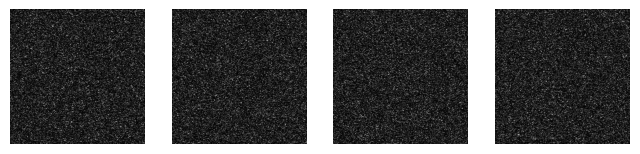

In [12]:
model, scheduler = train(input_size=(1, 28, 28), epochs=10, batch_size=32, lr=1e-3)
sample_images(model, scheduler, num_images=4, image_size=(1, 480, 480))